# Connected Fleet Telemetry — Exploratory Data Analysis
**Dataset:** Microsoft Azure Predictive Maintenance (Kaggle)  
**Goal:** Understand sensor behavior, failure distributions, and error patterns across a fleet of machines before building the predictive pipeline.

### Dataset Files
| File | Description |
|------|-------------|
| `PdM_telemetry.csv` | Hourly sensor readings (volt, rotate, pressure, vibration) — 876k rows |
| `PdM_failures.csv` | Component failure events with timestamps |
| `PdM_errors.csv` | On-board diagnostic error codes |
| `PdM_machines.csv` | Fleet metadata — vehicle age and model type |
| `PdM_maint.csv` | Historical maintenance records |

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings

warnings.filterwarnings('ignore') #suppresses any pesky warnings
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

DATA_DIR = '../data/raw/'
print('Libraries loaded ✅')

Libraries loaded ✅


## 1. Load Datasets

In [2]:
telemetry = pd.read_csv(DATA_DIR + 'PdM_telemetry.csv', parse_dates=['datetime'])
failures  = pd.read_csv(DATA_DIR + 'PdM_failures.csv',  parse_dates=['datetime'])
errors    = pd.read_csv(DATA_DIR + 'PdM_errors.csv',    parse_dates=['datetime'])
machines  = pd.read_csv(DATA_DIR + 'PdM_machines.csv')
maint     = pd.read_csv(DATA_DIR + 'PdM_maint.csv',     parse_dates=['datetime'])

print(f'Telemetry rows  : {len(telemetry):,}')
print(f'Failure events  : {len(failures):,}')
print(f'Error events    : {len(errors):,}')
print(f'Fleet size      : {machines["machineID"].nunique()} machines')
print(f'Maintenance logs: {len(maint):,}')

Telemetry rows  : 876,100
Failure events  : 761
Error events    : 3,919
Fleet size      : 100 machines
Maintenance logs: 3,286


## 2. Telemetry — Basic Overview

In [3]:
print('--- Schema ---')
telemetry.info()
print('\n--- Descriptive Statistics ---')
telemetry.describe().round(2)

--- Schema ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 876100 entries, 0 to 876099
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   datetime   876100 non-null  datetime64[ns]
 1   machineID  876100 non-null  int64         
 2   volt       876100 non-null  float64       
 3   rotate     876100 non-null  float64       
 4   pressure   876100 non-null  float64       
 5   vibration  876100 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 40.1 MB

--- Descriptive Statistics ---


,datetime,machineID,volt,rotate,pressure,vibration
count,876100,876100.00,876100.00,876100.00,876100.00,876100.00
mean,2015-07-02 18:00:00,50.50,170.78,446.61,100.86,40.39
min,2015-01-01 06:00:00,1.00,97.33,138.43,51.24,14.88
25%,2015-04-02 12:00:00,25.75,160.30,412.31,93.50,36.78
50%,2015-07-02 18:00:00,50.50,170.61,447.56,100.43,40.24
75%,2015-10-02 00:00:00,75.25,181.00,482.18,107.56,43.78
max,2016-01-01 06:00:00,100.00,255.12,695.02,185.95,76.79
std,NaN,28.87,15.51,52.67,11.05,5.37


In [4]:
# Missing value audit
print('=== Missing Values ===')
for df, name in [(telemetry,'telemetry'),(failures,'failures'),(errors,'errors'),(machines,'machines'),(maint,'maint')]:
    missing = df.isnull().sum().sum()
    print(f'  {name:12s}: {missing} missing values')

=== Missing Values ===
  telemetry   : 0 missing values
  failures    : 0 missing values
  errors      : 0 missing values
  machines    : 0 missing values
  maint       : 0 missing values


## 3. Sensor Distribution Analysis

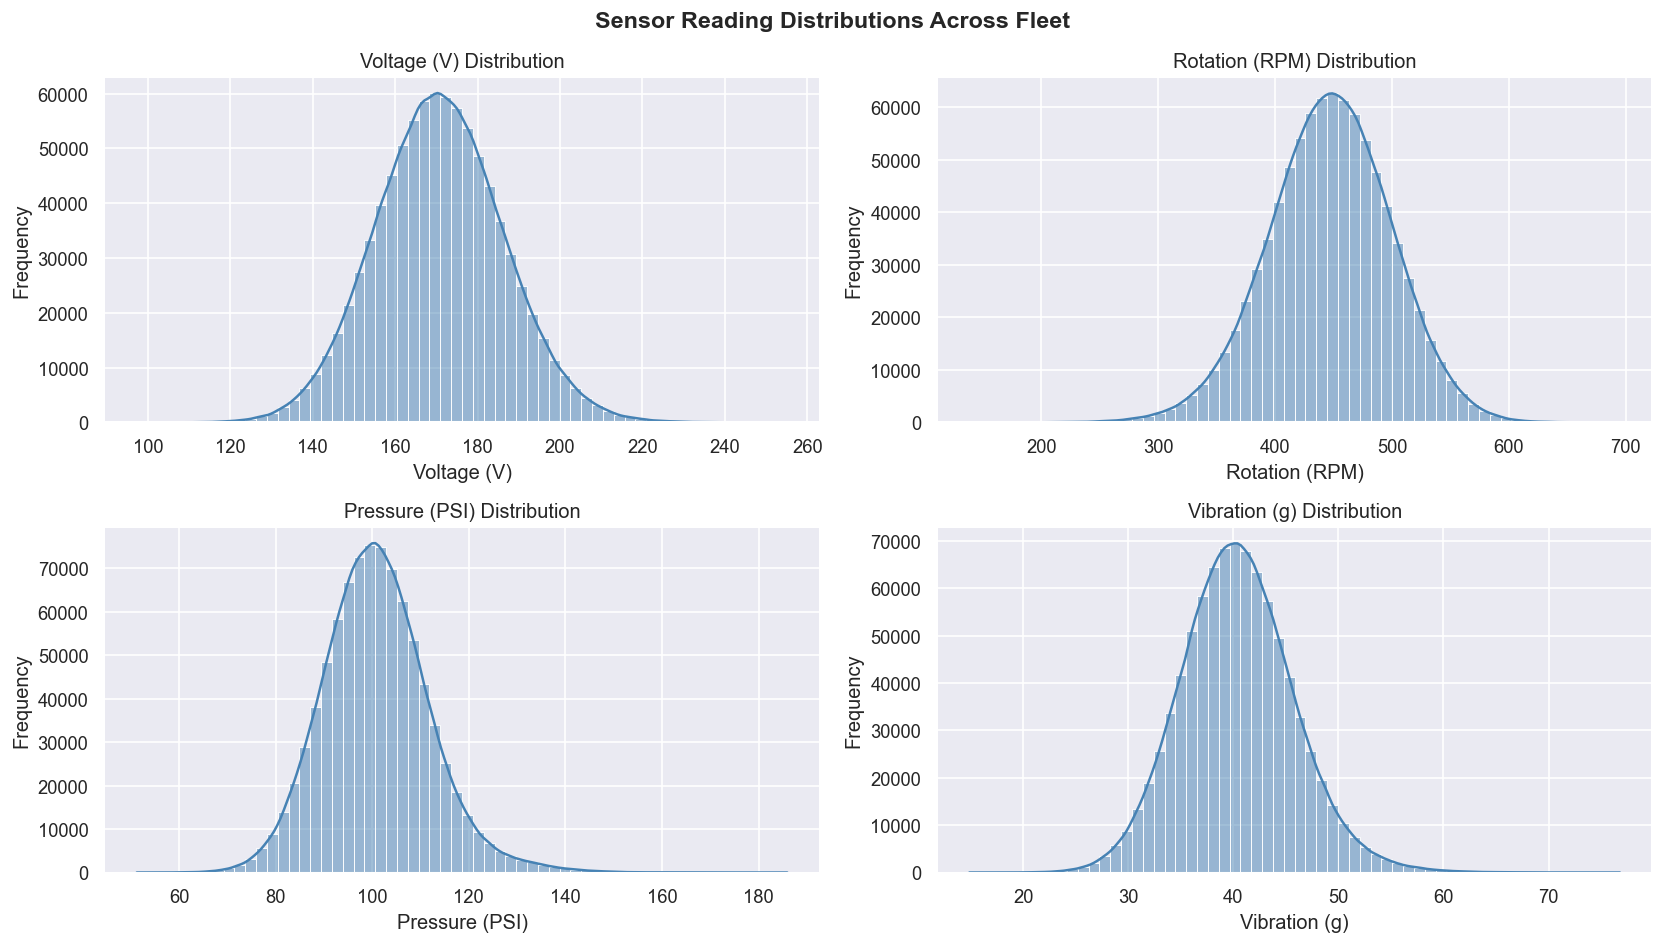

In [5]:
sensors = ['volt', 'rotate', 'pressure', 'vibration']
sensor_labels = {'volt': 'Voltage (V)', 'rotate': 'Rotation (RPM)',
                 'pressure': 'Pressure (PSI)', 'vibration': 'Vibration (g)'}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Sensor Reading Distributions Across Fleet', fontsize=14, fontweight='bold')

for ax, sensor in zip(axes.flatten(), sensors):
    sns.histplot(telemetry[sensor], bins=60, kde=True, ax=ax, color='steelblue')
    ax.set_xlabel(sensor_labels[sensor])
    ax.set_ylabel('Frequency')
    ax.set_title(f'{sensor_labels[sensor]} Distribution')

plt.tight_layout()
plt.savefig('../data/raw/sensor_distributions.png', bbox_inches='tight')
plt.show()

## 4. Time-Series Sensor Readings — Single Vehicle Deep Dive

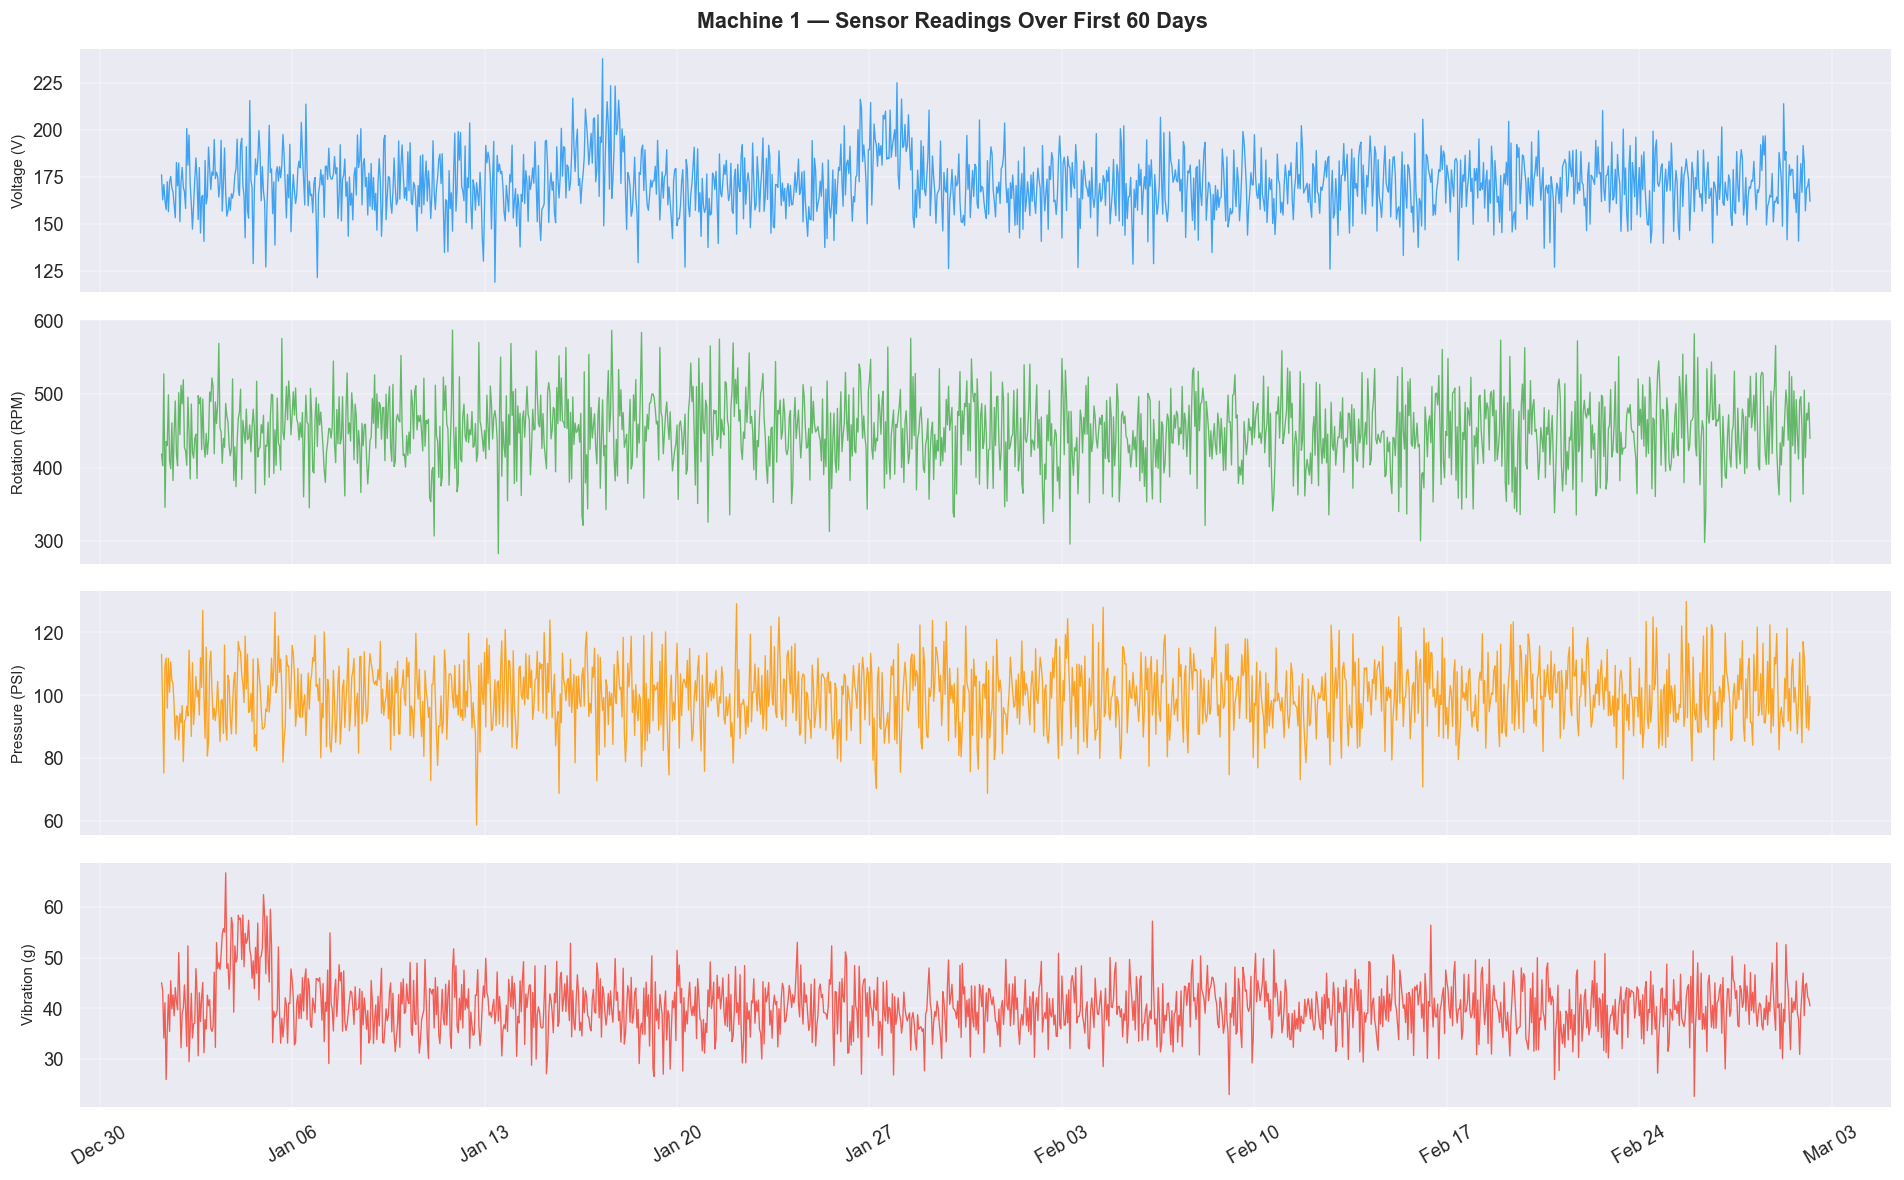

In [6]:
# Examine Machine 1 readings for first 60 days
m1 = telemetry[telemetry['machineID'] == 1].copy()
m1_window = m1[m1['datetime'] < m1['datetime'].min() + pd.Timedelta(days=60)]

fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)
fig.suptitle('Machine 1 — Sensor Readings Over First 60 Days', fontsize=13, fontweight='bold')

colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']
for ax, sensor, color in zip(axes, sensors, colors):
    ax.plot(m1_window['datetime'], m1_window[sensor], color=color, linewidth=0.8, alpha=0.85)
    ax.set_ylabel(sensor_labels[sensor], fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
axes[-1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 5. Failure Analysis

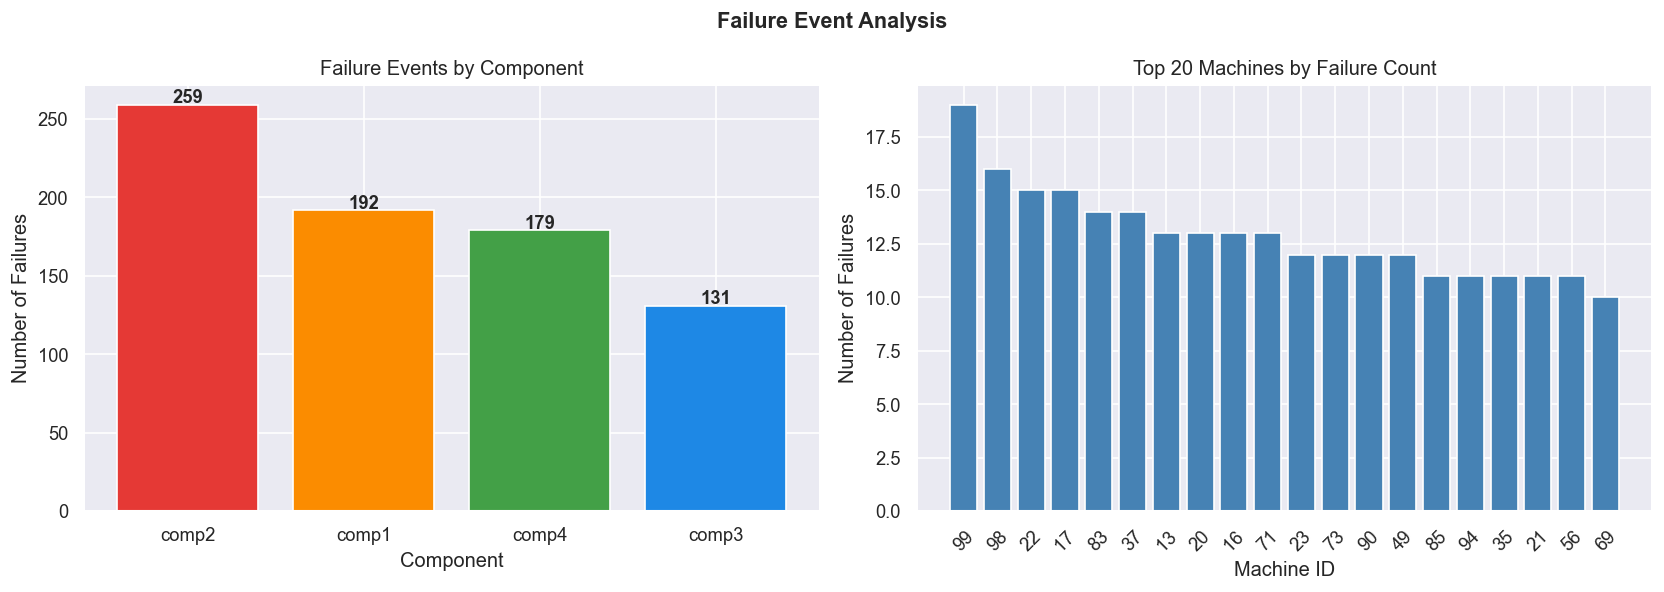

Total failure events : 761
Unique machines with failures: 98
Most common failure  : comp2 (259 events)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Failure Event Analysis', fontsize=13, fontweight='bold')

# Failure count by component
failure_counts = failures['failure'].value_counts()
axes[0].bar(failure_counts.index, failure_counts.values, color=['#E53935','#FB8C00','#43A047','#1E88E5'])
axes[0].set_title('Failure Events by Component')
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Number of Failures')
for i, v in enumerate(failure_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Failure count per machine
machine_failures = failures.groupby('machineID').size().sort_values(ascending=False).head(20)
axes[1].bar(machine_failures.index.astype(str), machine_failures.values, color='steelblue')
axes[1].set_title('Top 20 Machines by Failure Count')
axes[1].set_xlabel('Machine ID')
axes[1].set_ylabel('Number of Failures')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f'Total failure events : {len(failures)}')
print(f'Unique machines with failures: {failures["machineID"].nunique()}')
print(f'Most common failure  : {failure_counts.index[0]} ({failure_counts.values[0]} events)')

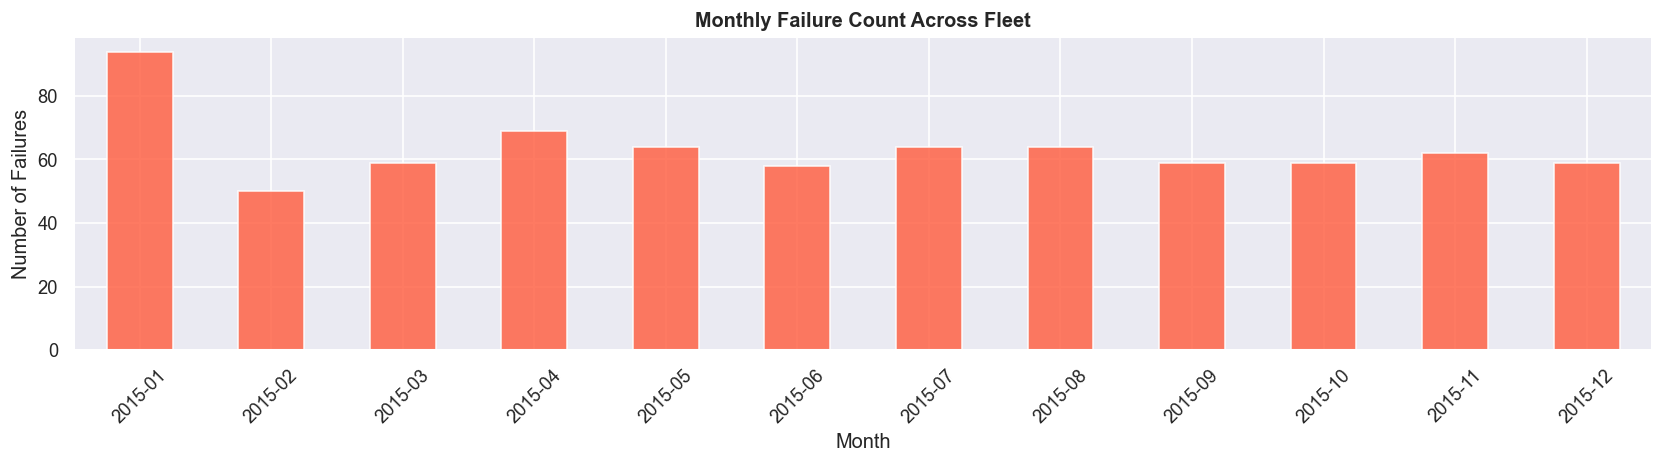

In [8]:
# Monthly failure trend
failures['month'] = failures['datetime'].dt.to_period('M')
monthly = failures.groupby('month').size()

plt.figure(figsize=(14, 4))
monthly.plot(kind='bar', color='tomato', alpha=0.85)
plt.title('Monthly Failure Count Across Fleet', fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Failures')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Sensor Correlation Heatmap

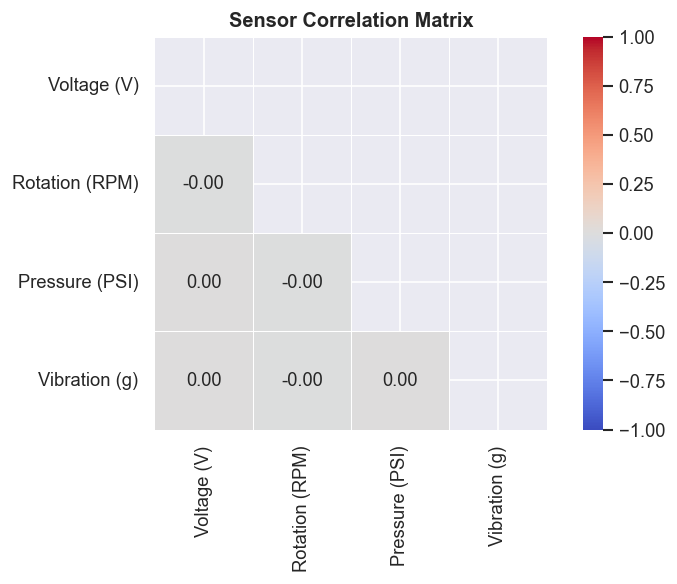

In [9]:
plt.figure(figsize=(7, 5))
corr = telemetry[sensors].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', mask=mask,
            vmin=-1, vmax=1, linewidths=0.5, square=True,
            xticklabels=[sensor_labels[s] for s in sensors],
            yticklabels=[sensor_labels[s] for s in sensors])
plt.title('Sensor Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Fleet Metadata — Machine Model & Age Analysis

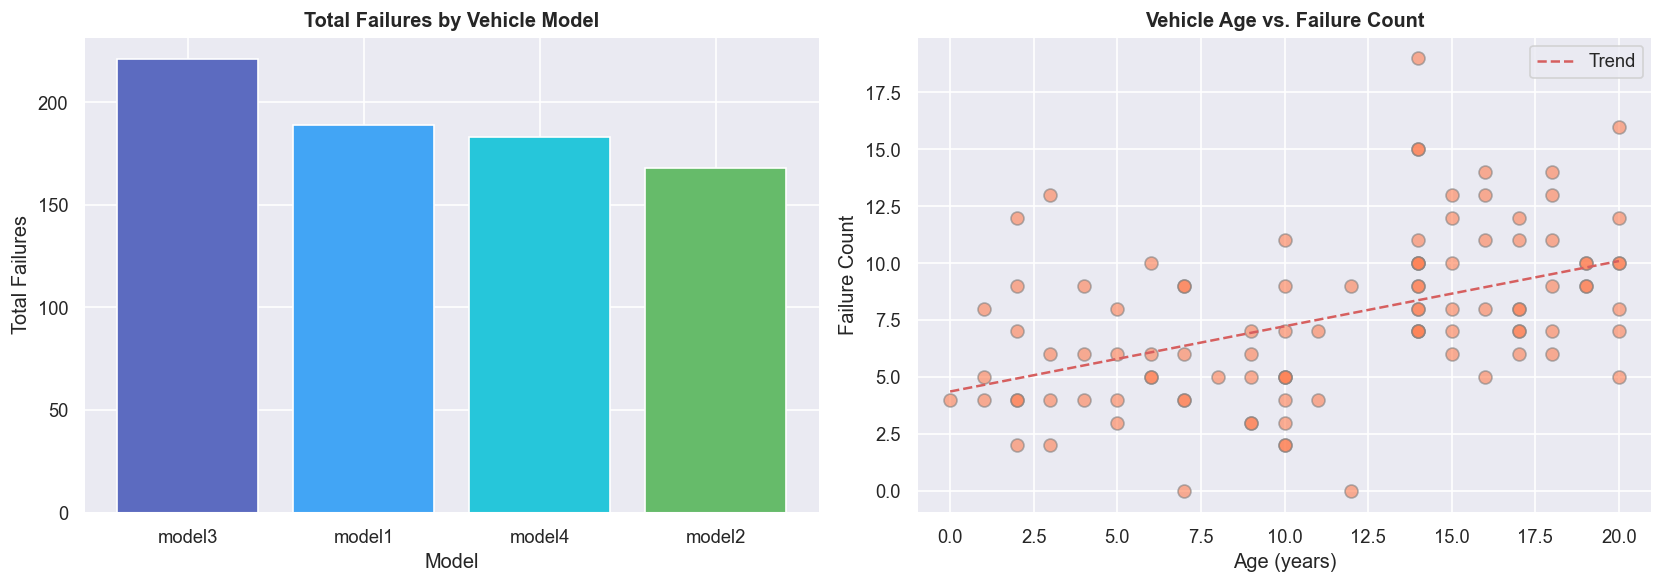


Failure rate stats by model:
         mean  max  sum
model                  
model1  11.81   19  189
model2   9.88   16  168
model3   6.31   10  221
model4   5.72   14  183


In [10]:
# Merge machine metadata with failure counts
machine_fail_count = failures.groupby('machineID').size().reset_index(name='failure_count')
fleet_df = machines.merge(machine_fail_count, on='machineID', how='left').fillna(0)
fleet_df['failure_count'] = fleet_df['failure_count'].astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Failures by model type
model_failures = fleet_df.groupby('model')['failure_count'].sum().sort_values(ascending=False)
axes[0].bar(model_failures.index, model_failures.values, color=['#5C6BC0','#42A5F5','#26C6DA','#66BB6A'])
axes[0].set_title('Total Failures by Vehicle Model', fontweight='bold')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Total Failures')

# Age vs failure count scatter
axes[1].scatter(fleet_df['age'], fleet_df['failure_count'], alpha=0.6, color='coral', edgecolor='gray', s=60)
z = np.polyfit(fleet_df['age'], fleet_df['failure_count'], 1)
p = np.poly1d(z)
x_line = np.linspace(fleet_df['age'].min(), fleet_df['age'].max(), 100)
axes[1].plot(x_line, p(x_line), 'r--', linewidth=1.5, label='Trend')
axes[1].set_title('Vehicle Age vs. Failure Count', fontweight='bold')
axes[1].set_xlabel('Age (years)')
axes[1].set_ylabel('Failure Count')
axes[1].legend()

plt.tight_layout()
plt.show()

print('\nFailure rate stats by model:')
print(fleet_df.groupby('model')['failure_count'].agg(['mean','max','sum']).round(2))

## 8. Error Code Frequency Analysis

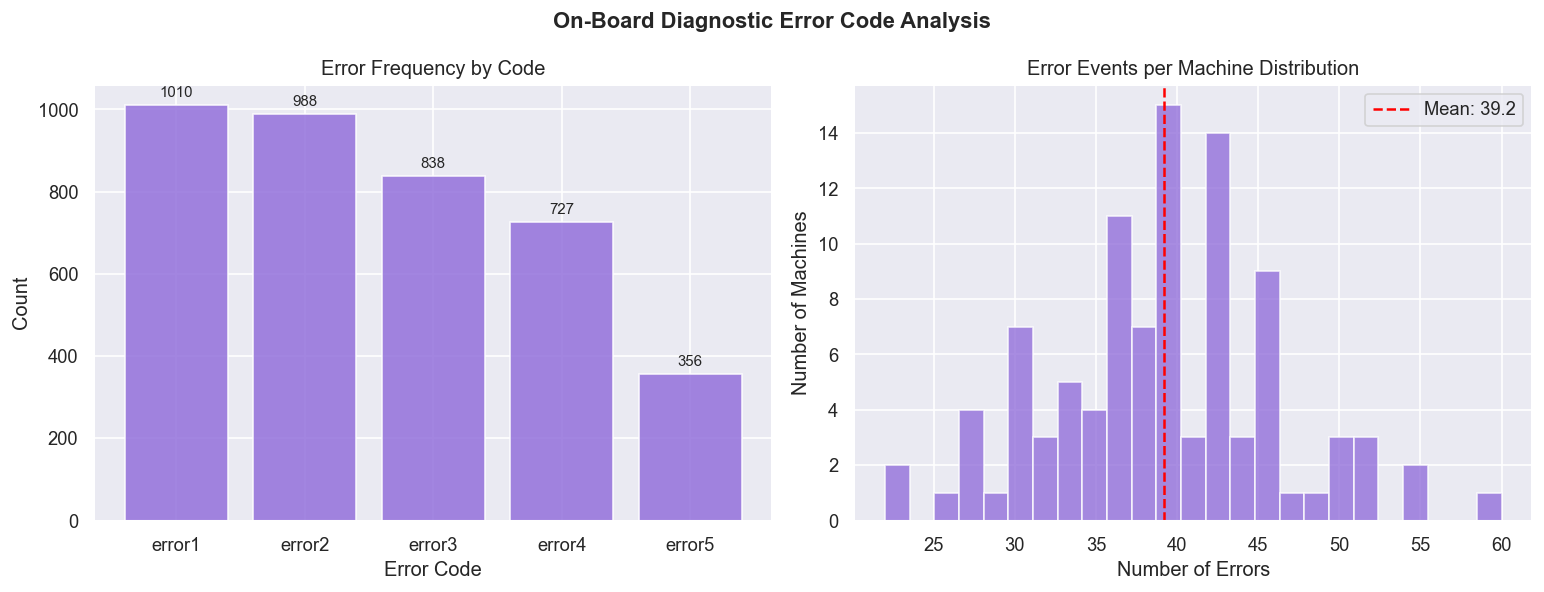

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('On-Board Diagnostic Error Code Analysis', fontweight='bold')

# Error frequency
error_counts = errors['errorID'].value_counts()
axes[0].bar(error_counts.index, error_counts.values, color='mediumpurple', alpha=0.85)
axes[0].set_title('Error Frequency by Code')
axes[0].set_xlabel('Error Code')
axes[0].set_ylabel('Count')
for i, v in enumerate(error_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontsize=9)

# Errors per machine histogram
errors_per_machine = errors.groupby('machineID').size()
axes[1].hist(errors_per_machine, bins=25, color='mediumpurple', alpha=0.8, edgecolor='white')
axes[1].axvline(errors_per_machine.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {errors_per_machine.mean():.1f}')
axes[1].set_title('Error Events per Machine Distribution')
axes[1].set_xlabel('Number of Errors')
axes[1].set_ylabel('Number of Machines')
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Sensor Behavior — Pre vs. Post Failure Windows
Do sensors show anomalous readings in the hours leading up to a failure?

In [12]:
# Merge telemetry with failure labels
tel = telemetry.merge(machines, on='machineID')

# Create 'hours_to_failure' flag — mark 24h windows before each failure
def mark_pre_failure(group_tel, group_fail, hours=24):
    label = pd.Series(0, index=group_tel.index)
    for _, frow in group_fail.iterrows():
        window_start = frow['datetime'] - pd.Timedelta(hours=hours)
        mask = (group_tel['datetime'] >= window_start) & (group_tel['datetime'] < frow['datetime'])
        label[mask] = 1
    return label

telemetry_labeled = telemetry.copy()
telemetry_labeled['pre_failure'] = 0
for mid in telemetry_labeled['machineID'].unique():
    t_mask = telemetry_labeled['machineID'] == mid
    f_mask = failures['machineID'] == mid
    telemetry_labeled.loc[t_mask, 'pre_failure'] = mark_pre_failure(
        telemetry_labeled[t_mask], failures[f_mask]
    ).values

print(f"Pre-failure rows : {telemetry_labeled['pre_failure'].sum():,}")
print(f"Normal rows      : {(telemetry_labeled['pre_failure']==0).sum():,}")
print(f"Class imbalance  : {telemetry_labeled['pre_failure'].mean()*100:.2f}% failure windows")

Pre-failure rows : 17,184
Normal rows      : 858,916
Class imbalance  : 1.96% failure windows


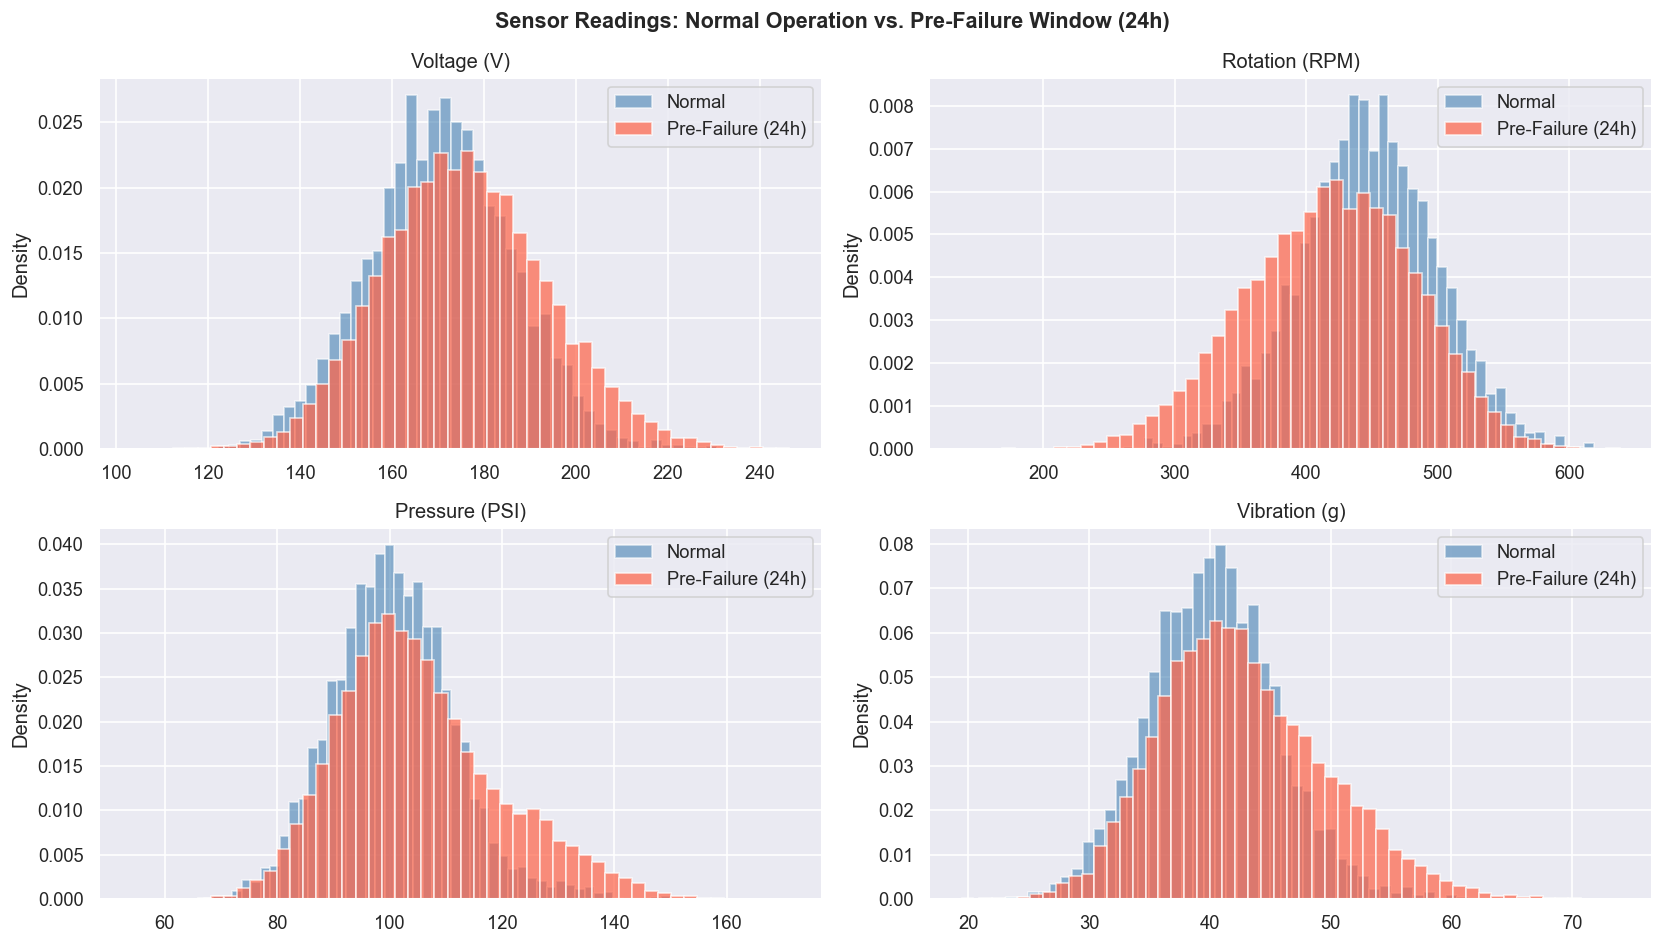

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Sensor Readings: Normal Operation vs. Pre-Failure Window (24h)', fontsize=13, fontweight='bold')

for ax, sensor in zip(axes.flatten(), sensors):
    normal = telemetry_labeled[telemetry_labeled['pre_failure'] == 0][sensor]
    pre_fail = telemetry_labeled[telemetry_labeled['pre_failure'] == 1][sensor]
    ax.hist(normal.sample(min(5000, len(normal))), bins=50, alpha=0.6, label='Normal', color='steelblue', density=True)
    ax.hist(pre_fail, bins=50, alpha=0.7, label='Pre-Failure (24h)', color='tomato', density=True)
    ax.set_title(sensor_labels[sensor])
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.show()

## 10. Key EDA Insights

| Finding | Detail |
|---------|--------|
| **No missing values** | All 5 datasets are complete — no imputation required |
| **Class imbalance** | Only ~2% of readings occur in 24h pre-failure windows — requires SMOTE or class weighting |
| **Age-failure correlation** | Older machines (10+ years) show a clear upward trend in failure frequency |
| **Sensor shift pre-failure** | Vibration and pressure show measurable distribution shifts in 24h before failure |
| **Component 2 most common failure** | comp2 accounts for the highest failure count across the fleet |